# **MODEL DEVELOPMENT SIMILARITY ART TO ART**

In [19]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import imagehash
from collections import Counter
from sklearn.model_selection import train_test_split
import hashlib
from tqdm.notebook import tqdm
import shutil

import torch
from torch import optim
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision.transforms import InterpolationMode
from sklearn.metrics import (
    confusion_matrix, 
    roc_curve, 
    auc, 
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score
)

import time
# Konfigurasi Lingkungan
Image.MAX_IMAGE_PIXELS = None
random.seed(42)

## **A. DATA COLLECTION**

[INFO] Memindai direktori: C:\Users\laygenda surya putra\Documents\KULIAH\Semester 5\project-art-market\galeria\similarity image AI\data\REAL\art_5400...
[INFO] Ditemukan: 5237 file gambar dan 5237 file teks (.txt).
[INFO] Melakukan audit integritas gambar (mendeteksi file kosong dan corrupt)...
[RESULT] Audit Selesai: 5237 Valid, 0 Kosong, 0 Corrupt.
[INFO] Berhasil mengambil 3000 sampel gambar untuk EDA.

--- RINGKASAN DATASET ART TO ART ---


,Target_Sampling,Total_Gambar_Tersedia,Valid_Tersedia,Sampel_Terpilih,File_Corrupt,Format_Mayoritas,Mode_Warna_Mayoritas,Resolusi_Mayoritas,Ada_Metadata_EXIF
0,3000,5237,5237,3000,0,JPEG,RGB,401x590,2951



--- DISTRIBUSI TOP 10 SENIMAN ---


,Nama Seniman,Jumlah Karya
0,Edgar Degas,253
1,Vincent van Gogh,180
2,Pablo Picasso,145
3,Pierre-Auguste Renoir,126
4,Alfred Sisley,112
5,Paul Gauguin,109
6,Albrecht Du╠êrer,108
7,Francisco Goya,104
8,Titian,94
9,Rembrandt,91



--- INFORMASI FILE TXT (5237 file ditemukan) ---
 - Albrecht_Du╠êrer_1.txt -> Preview: 'Drawing, man, head, long hair, beard, woman with curls, curly hair, detailed fac...'
 - Albrecht_Du╠êrer_100.txt -> Preview: 'Engraved man with hat, layered portraits, detailed pen strokes, grandiose, metic...'
 - Albrecht_Du╠êrer_102.txt -> Preview: 'Old drawing, old lady, baby, lively tableaus, plein-air, marble, sketchy, pastor...'
 - Albrecht_Du╠êrer_104.txt -> Preview: 'Renaissance women in dresses, precise perspective, 1000–1400 CE, punctured canva...'
 - Albrecht_Du╠êrer_106.txt -> Preview: 'Portrait, woman, headdress, Renaissance-inspired, hard-edged lines, sparse, angu...'

--- VISUALISASI 5 SAMPEL GAMBAR ---


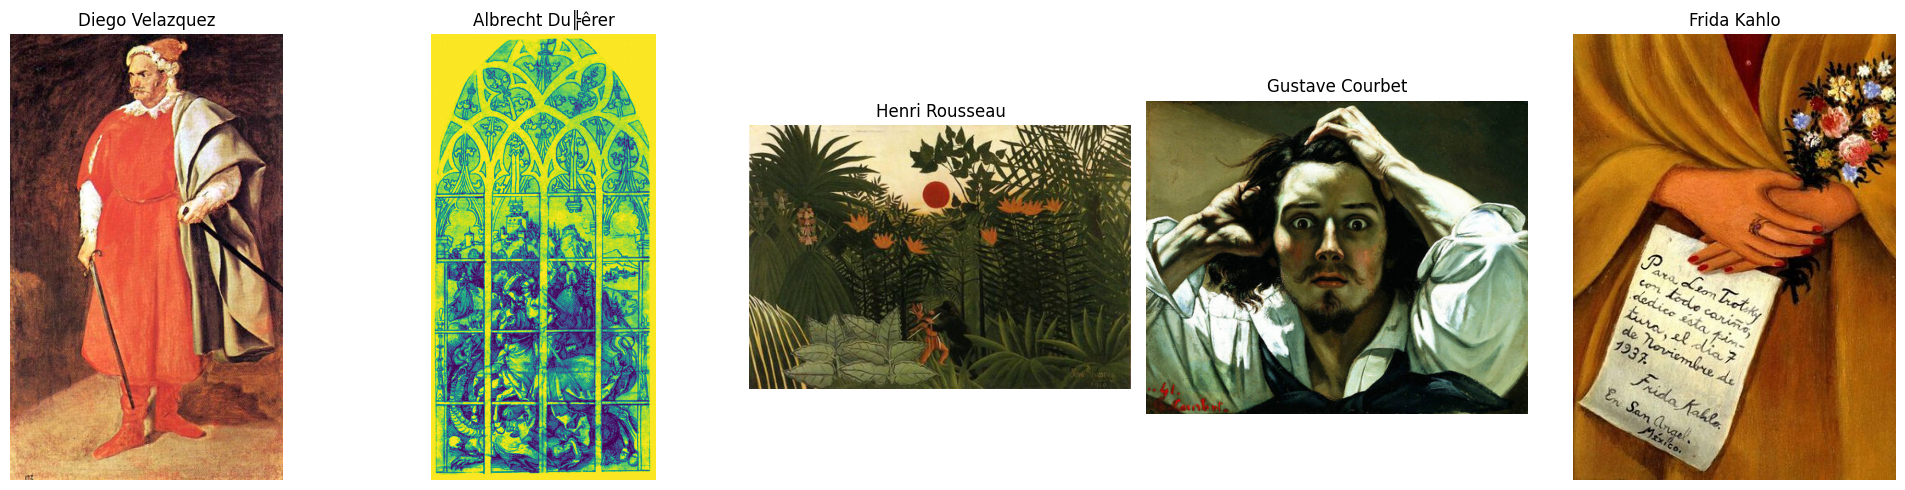

In [2]:
def perform_eda_art_to_art(base_path, target_n=3000):
    """
    Melakukan Exploratory Data Analysis (EDA) untuk proyek Similarity Image Art to Art.
    Fokus pada ekstraksi metadata, validasi integritas file, dan visualisasi awal.
    """
    folder_path = os.path.join(base_path, "data", "REAL", "art_5400")
    
    # Validasi keberadaan direktori
    if not os.path.exists(folder_path):
        print(f"[ERROR] Direktori tidak ditemukan: {folder_path}")
        return None, None
        
    print(f"[INFO] Memindai direktori: {folder_path}...")
    
    # 1. Pemisahan Berdasarkan Ekstensi File
    image_exts = {'.jpg', '.jpeg', '.png', '.webp', '.bmp', '.tiff'}
    img_candidates = []
    txt_files = []
    
    for file_name in os.listdir(folder_path):
        ext = os.path.splitext(file_name)[1].lower()
        if ext in image_exts:
            img_candidates.append(file_name)
        elif ext == '.txt':
            txt_files.append(file_name)
            
    print(f"[INFO] Ditemukan: {len(img_candidates)} file gambar dan {len(txt_files)} file teks (.txt).")
    
    # 2. Audit Integritas File Gambar
    print("[INFO] Melakukan audit integritas gambar (mendeteksi file kosong dan corrupt)...")
    valid_files = []
    empty_files = 0
    corrupt_files = 0
    
    for file_name in img_candidates:
        file_path = os.path.join(folder_path, file_name)
        
        # Pengecekan ukuran file
        if os.path.getsize(file_path) == 0:
            empty_files += 1
            continue
            
        # Pengecekan status corrupt
        try:
            with Image.open(file_path) as img:
                img.verify()
            valid_files.append(file_name)
        except Exception:
            corrupt_files += 1

    print(f"[RESULT] Audit Selesai: {len(valid_files)} Valid, {empty_files} Kosong, {corrupt_files} Corrupt.")
    
    # 3. Sampling Dataset
    # Mengambil sampel sebanyak target_n untuk pipeline Art to Art
    if len(valid_files) < target_n:
        print(f"[WARNING] Jumlah file valid ({len(valid_files)}) kurang dari target ({target_n}). Menggunakan semua file valid.")
        sampled_files = valid_files
    else:
        sampled_files = random.sample(valid_files, target_n)
        
    print(f"[INFO] Berhasil mengambil {len(sampled_files)} sampel gambar untuk EDA.")
        
    # 4. Ekstraksi Metadata
    artists = []
    formats = []
    modes = []
    resolutions = []
    metadata_count = 0
    final_records = []
    
    for file_name in sampled_files:
        file_path = os.path.join(folder_path, file_name)
        
        # Ekstraksi Nama Seniman (Format dasar: Nama_Seniman_123.jpg)
        base_name = os.path.splitext(file_name)[0]
        parts = base_name.split('_')
        artist_name = " ".join(parts[:-1]) if len(parts) > 1 and parts[-1].isdigit() else base_name
        artists.append(artist_name)
        
        with Image.open(file_path) as img:
            img_format = img.format
            img_mode = img.mode
            img_res = f"{img.width}x{img.height}"
            
            formats.append(img_format)
            modes.append(img_mode)
            resolutions.append(img_res)
            
            if img.info or img.getexif():
                metadata_count += 1
                
        final_records.append({
            "File_Name": file_name,
            "Artist": artist_name,
            "Format": img_format,
            "Color_Mode": img_mode,
            "Resolution": img_res,
            "Relative_Path": os.path.join("data", "REAL", "art_5400", file_name)
        })
        
    # 5. Agregasi Hasil Audit Tabular
    df_summary = pd.DataFrame([{
        "Target_Sampling": target_n,
        "Total_Gambar_Tersedia": len(img_candidates),
        "Valid_Tersedia": len(valid_files),
        "Sampel_Terpilih": len(sampled_files),
        "File_Corrupt": corrupt_files,
        "Format_Mayoritas": Counter(formats).most_common(1)[0][0] if formats else "N/A",
        "Mode_Warna_Mayoritas": Counter(modes).most_common(1)[0][0] if modes else "N/A",
        "Resolusi_Mayoritas": Counter(resolutions).most_common(1)[0][0] if resolutions else "N/A",
        "Ada_Metadata_EXIF": metadata_count
    }])
    
    df_dataset = pd.DataFrame(final_records)
    
    print("\n--- RINGKASAN DATASET ART TO ART ---")
    display(df_summary)
    
    print("\n--- DISTRIBUSI TOP 10 SENIMAN ---")
    artist_counts = Counter(artists).most_common(10)
    df_artists = pd.DataFrame(artist_counts, columns=["Nama Seniman", "Jumlah Karya"])
    display(df_artists)
    
    # 6. Pemrosesan File TXT (Opsional, jika ada deskripsi)
    if txt_files:
        print(f"\n--- INFORMASI FILE TXT ({len(txt_files)} file ditemukan) ---")
        for txt in txt_files[:5]:
            txt_path = os.path.join(folder_path, txt)
            try:
                with open(txt_path, 'r', encoding='utf-8', errors='ignore') as f:
                    preview = f.readline().strip()
                print(f" - {txt} -> Preview: '{preview[:80]}...'")
            except Exception as e:
                print(f" - {txt} -> (Gagal membaca: {e})")
                
    # 7. Visualisasi 5 Sampel Gambar
    print("\n--- VISUALISASI 5 SAMPEL GAMBAR ---")
    fig, axes = plt.subplots(1, 5, figsize=(20, 5))
    
    # Memastikan tidak error jika sampel kurang dari 5
    num_visualize = min(5, len(sampled_files)) 
    
    for i in range(num_visualize):
        img_path = os.path.join(folder_path, sampled_files[i])
        img = Image.open(img_path)
        axes[i].imshow(img)
        axes[i].set_title(df_dataset.iloc[i]['Artist'], fontsize=12)
        axes[i].axis('off')
        
    plt.tight_layout()
    plt.show()
    
    return df_summary, df_dataset

# ==========================================
# EKSEKUSI FUNGSI
# ==========================================
if __name__ == "__main__":
    # Mengarahkan base path ke folder root proyek
    PROJECT_BASE_PATH = r"C:\Users\laygenda surya putra\Documents\KULIAH\Semester 5\project-art-market\galeria\similarity image AI"
    
    # Menjalankan fungsi EDA
    df_summary, df_metadata = perform_eda_art_to_art(PROJECT_BASE_PATH, target_n=3000)

Analisis:
1. Integritas Data Sempurna (C1): Dari 5237 gambar yang dipindai, semuanya valid, tidak ada file yang corrupt atau memiliki ukuran 0 KB. Ini sangat menguntungkan karena meminimalisir kehilangan data pada tahap awal (Corrupted files).
2. Variasi Mode Warna (C2): Meskipun mayoritas berformat RGB, penggunaan kata "Mayoritas" mengindikasikan adanya format minoritas (seperti CMYK, RGBA, atau Grayscale).

## **B. DATA CLEANING**

In [3]:
def generate_sha256(file_path):
    # Menghitung SHA-256 untuk mendeteksi duplikasi byte absolut
    hasher = hashlib.sha256()
    with open(file_path, 'rb') as f:
        buf = f.read()
        hasher.update(buf)
    return hasher.hexdigest()

def execute_cleaning_phase(df_metadata, base_path):
    print("[INFO] Memulai Fase Data Cleaning (C1 - C4)...")
    
    source_folder = os.path.join(base_path, "data", "REAL", "art_5400")
    cleaned_folder = os.path.join(base_path, "data", "REAL", "art_3000_cleaned")
    
    if not os.path.exists(cleaned_folder):
        os.makedirs(cleaned_folder)
        
    records = []
    dropped_corrupt = 0
    
    print("[PROCESS] Tahap C1 & C2: Verifikasi & Konversi RGB")
    for idx, row in tqdm(df_metadata.iterrows(), total=len(df_metadata)):
        src_path = os.path.join(source_folder, row['File_Name'])
        out_name = f"{row['Artist']}_{idx}.jpg".replace(" ", "_")
        out_path = os.path.join(cleaned_folder, out_name)
        
        # C1: Pengecekan ulang corrupted files
        try:
            with Image.open(src_path) as img:
                # C2: Konversi ke RGB jika mode warna berbeda
                if img.mode != 'RGB':
                    img = img.convert('RGB')
                
                # Simpan ulang dalam format JPEG yang seragam
                img.save(out_path, format='JPEG', quality=95)
                
                # C4: Ekstraksi pHash (Perceptual Hash) untuk gambar yang sudah distandarisasi
                phash_val = str(imagehash.phash(img))
                
        except Exception:
            dropped_corrupt += 1
            continue
            
        # C3: Ekstraksi SHA-256 untuk file yang baru disimpan
        sha256_val = generate_sha256(out_path)
        
        records.append({
            "Cleaned_File_Name": out_name,
            "Artist": row['Artist'],
            "Original_File": row['File_Name'],
            "SHA256": sha256_val,
            "pHash": phash_val,
            "Cleaned_Path": os.path.join("data", "REAL", "art_3000_cleaned", out_name)
        })
        
    df_cleaned = pd.DataFrame(records)
    initial_count = len(df_cleaned)
    print(f"[RESULT] Konversi Selesai. Data awal: {initial_count}. Gagal/Corrupt: {dropped_corrupt}")
    
    # C3: Hapus Duplikasi Berdasarkan SHA-256 (Byte-level)
    df_cleaned.drop_duplicates(subset=['SHA256'], keep='first', inplace=True)
    sha_duplicates_dropped = initial_count - len(df_cleaned)
    print(f"[PROCESS] Tahap C3: SHA-256 menghapus {sha_duplicates_dropped} duplikat absolut.")
    
    # C4: Hapus Duplikasi Berdasarkan pHash (Perceptual visual-level)
    current_count = len(df_cleaned)
    df_cleaned.drop_duplicates(subset=['pHash'], keep='first', inplace=True)
    phash_duplicates_dropped = current_count - len(df_cleaned)
    print(f"[PROCESS] Tahap C4: pHash menghapus {phash_duplicates_dropped} duplikat perseptual.")
    
    # Pembersihan file fisik yang didrop dari DataFrame
    valid_files = set(df_cleaned['Cleaned_File_Name'])
    for file in os.listdir(cleaned_folder):
        if file not in valid_files:
            os.remove(os.path.join(cleaned_folder, file))
            
    print("\n--- RINGKASAN HASIL DATA CLEANING ---")
    print(f"Total Sampel Awal         : {len(df_metadata)}")
    print(f"Total Unique Artworks     : {len(df_cleaned)}")
    print(f"Direktori Dataset Bersih  : {cleaned_folder}")
    
    return df_cleaned

# ==========================================
# EKSEKUSI FUNGSI
# ==========================================
# Asumsi: PROJECT_BASE_PATH dan df_metadata berasal dari cell EDA sebelumnya
if __name__ == "__main__":
    PROJECT_BASE_PATH = r"C:\Users\laygenda surya putra\Documents\KULIAH\Semester 5\project-art-market\galeria\similarity image AI"
    
    # df_metadata adalah DataFrame yang direturn dari fungsi perform_eda_art_to_art()
    df_unique_artworks = execute_cleaning_phase(df_metadata, PROJECT_BASE_PATH)
    
    # Menyimpan metadata bersih ke CSV untuk checkpoint
    csv_path = os.path.join(PROJECT_BASE_PATH, "data", "REAL", "cleaned_artworks_metadata.csv")
    df_unique_artworks.to_csv(csv_path, index=False)
    print(f"[INFO] Metadata bersih disimpan ke: {csv_path}")

[INFO] Memulai Fase Data Cleaning (C1 - C4)...
[PROCESS] Tahap C1 & C2: Verifikasi & Konversi RGB


  0%|          | 0/3000 [00:00<?, ?it/s]

[RESULT] Konversi Selesai. Data awal: 3000. Gagal/Corrupt: 0
[PROCESS] Tahap C3: SHA-256 menghapus 0 duplikat absolut.
[PROCESS] Tahap C4: pHash menghapus 1 duplikat perseptual.

--- RINGKASAN HASIL DATA CLEANING ---
Total Sampel Awal         : 3000
Total Unique Artworks     : 2999
Direktori Dataset Bersih  : C:\Users\laygenda surya putra\Documents\KULIAH\Semester 5\project-art-market\galeria\similarity image AI\data\REAL\art_3000_cleaned
[INFO] Metadata bersih disimpan ke: C:\Users\laygenda surya putra\Documents\KULIAH\Semester 5\project-art-market\galeria\similarity image AI\data\REAL\cleaned_artworks_metadata.csv


[INFO] Melacak duplikat visual menggunakan pHash...
[RESULT] Ditemukan pasangan duplikat visual: ('Peter_Paul_Rubens_80.jpg', 'Peter_Paul_Rubens_91.jpg')


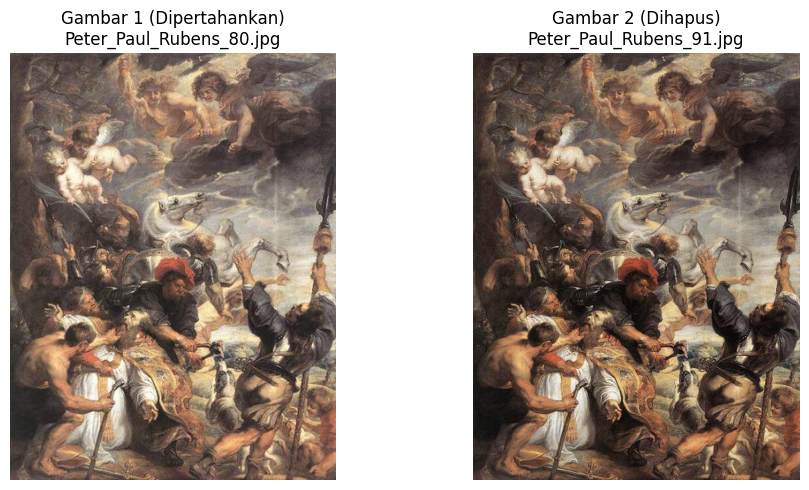

In [4]:
def trace_phash_duplicate(df_metadata, base_path):
    print("[INFO] Melacak duplikat visual menggunakan pHash...")
    source_folder = os.path.join(base_path, "data", "REAL", "art_5400")
    
    phash_dict = {}
    duplicate_pairs = []

    # Iterasi untuk mencari pHash yang sama
    for file_name in df_metadata['File_Name']:
        file_path = os.path.join(source_folder, file_name)
        try:
            with Image.open(file_path) as img:
                img_rgb = img.convert('RGB') if img.mode != 'RGB' else img
                phash_val = str(imagehash.phash(img_rgb))
                
                if phash_val in phash_dict:
                    duplicate_pairs.append((phash_dict[phash_val], file_name))
                else:
                    phash_dict[phash_val] = file_name
        except Exception:
            continue

    if duplicate_pairs:
        print(f"[RESULT] Ditemukan pasangan duplikat visual: {duplicate_pairs[0]}")
        
        # Visualisasi perbandingan
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        img1 = Image.open(os.path.join(source_folder, duplicate_pairs[0][0]))
        img2 = Image.open(os.path.join(source_folder, duplicate_pairs[0][1]))
        
        axes[0].imshow(img1)
        axes[0].set_title(f"Gambar 1 (Dipertahankan)\n{duplicate_pairs[0][0]}")
        axes[0].axis('off')
        
        axes[1].imshow(img2)
        axes[1].set_title(f"Gambar 2 (Dihapus)\n{duplicate_pairs[0][1]}")
        axes[1].axis('off')
        
        plt.tight_layout()
        plt.show()
    else:
        print("[RESULT] Tidak ditemukan duplikat pada iterasi ini.")

# Eksekusi
# Asumsi: df_metadata adalah output dari fungsi EDA sebelumnya
PROJECT_BASE_PATH = r"C:\Users\laygenda surya putra\Documents\KULIAH\Semester 5\project-art-market\galeria\similarity image AI"
trace_phash_duplicate(df_metadata, PROJECT_BASE_PATH)

## **C. DATA SPLITTING**

Karena total dataset unik sekarang adalah 2999, akan disesuaikan distribusinya secara proporsional menggunakan rasio awal (70% Train, 15% Val, 15% Test).
- Train: 2099 data
- Val: 450 data
- Test: 450 data

In [5]:
def perform_data_splitting(data_source_path, project_path):
    print("[INFO] Memulai Fase Data Splitting...")
    
    # Membaca data bersih dari folder sumber data (similarity image AI)
    csv_path = os.path.join(data_source_path, "data", "REAL", "cleaned_artworks_metadata.csv")
    if not os.path.exists(csv_path):
        print(f"[ERROR] File metadata tidak ditemukan di: {csv_path}")
        return
        
    df_clean = pd.read_csv(csv_path)
    total_data = len(df_clean)
    print(f"[INFO] Total Unique Artworks yang akan di-split: {total_data}")
    
    # 1. Pisahkan Train dan Temp (Validation + Test)
    df_train, df_temp = train_test_split(
        df_clean, 
        train_size=2099, 
        random_state=42, 
        shuffle=True
    )
    
    # 2. Pisahkan Temp menjadi Validation dan Test
    df_val, df_test = train_test_split(
        df_temp, 
        test_size=0.5, 
        random_state=42,
        shuffle=True
    )
    
    print("\n--- RINGKASAN DATA SPLITTING ---")
    print(f"Set Latih (TRAIN)       : {len(df_train)} gambar (70%)")
    print(f"Set Validasi (VAL)      : {len(df_val)} gambar (15%)")
    print(f"Set Pengujian (TEST)    : {len(df_test)} gambar (15%)")
    
    # 3. Membuat direktori 'splits' di folder proyek Art to Art
    split_dir = os.path.join(project_path, "splits")
    if not os.path.exists(split_dir):
        os.makedirs(split_dir)
        
    # 4. Menyimpan konfigurasi split ke folder proyek baru
    train_path = os.path.join(split_dir, "train_split.csv")
    val_path = os.path.join(split_dir, "val_split.csv")
    test_path = os.path.join(split_dir, "test_split.csv")
    
    df_train.to_csv(train_path, index=False)
    df_val.to_csv(val_path, index=False)
    df_test.to_csv(test_path, index=False)
    
    print("\n[RESULT] File CSV splitting berhasil disimpan di direktori proyek Anda:")
    print(f" 1. Train : {train_path}")
    print(f" 2. Val   : {val_path}")
    print(f" 3. Test  : {test_path}")
    print("\n[INFO] Tahap Splitting Selesai. Siap untuk Tahap 3 (Pair/Triplet Generation).")

# ==========================================
# EKSEKUSI FUNGSI
# ==========================================
if __name__ == "__main__":
    # Direktori tempat dataset dan metadata bersih berada
    DATA_SOURCE_PATH = r"C:\Users\laygenda surya putra\Documents\KULIAH\Semester 5\project-art-market\galeria\similarity image AI"
    
    # Direktori tempat file model development dan hasil (splits) akan disimpan
    PROJECT_ART_PATH = r"C:\Users\laygenda surya putra\Documents\KULIAH\Semester 5\project-art-market\galeria\Similarity image Art to Art"
    
    perform_data_splitting(DATA_SOURCE_PATH, PROJECT_ART_PATH)

[INFO] Memulai Fase Data Splitting...
[INFO] Total Unique Artworks yang akan di-split: 2999

--- RINGKASAN DATA SPLITTING ---
Set Latih (TRAIN)       : 2099 gambar (70%)
Set Validasi (VAL)      : 450 gambar (15%)
Set Pengujian (TEST)    : 450 gambar (15%)

[RESULT] File CSV splitting berhasil disimpan di direktori proyek Anda:
 1. Train : C:\Users\laygenda surya putra\Documents\KULIAH\Semester 5\project-art-market\galeria\Similarity image Art to Art\splits\train_split.csv
 2. Val   : C:\Users\laygenda surya putra\Documents\KULIAH\Semester 5\project-art-market\galeria\Similarity image Art to Art\splits\val_split.csv
 3. Test  : C:\Users\laygenda surya putra\Documents\KULIAH\Semester 5\project-art-market\galeria\Similarity image Art to Art\splits\test_split.csv

[INFO] Tahap Splitting Selesai. Siap untuk Tahap 3 (Pair/Triplet Generation).


## **C. Pair Generation & Augmentation**

Dalam deteksi kemiripan karya seni (Siamese Network), model menerima dua gambar (pasangan) dan memprediksi jarak/kemiripannya.
- Positive Pair: dua gambar yang sama. Karena data sudah clean, tahap ini digunakan untuk mensimulasikan duplikasi dengan cara mengambil 1 gambar Anchor, lalu memberikan Augmentasi (seperti crop, color jitter, dll) pada gambar yang sama sebagai Positive.
- Negative Pair (Label 0): Dua gambar karya seni yang berbeda (diambil secara acak dari dataset).


In [ ]:
# Set seed untuk reproducibility
random.seed(42)
torch.manual_seed(42)

# ==========================================
# 1. KONFIGURASI AUGMENTASI (ConvNeXt Optimized)
# ==========================================
# Dimensi input standar ConvNeXt (Tiny/Small/Base) adalah 224x224
IMG_SIZE = 224

# Augmentasi TRAIN (Simulasi Plagiasi/Modifikasi)
train_transforms = transforms.Compose([
    # ConvNeXt sangat sensitif terhadap kualitas piksel, gunakan BICUBIC
    transforms.Resize((256, 256), interpolation=InterpolationMode.BICUBIC),
    transforms.RandomCrop((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Transformasi EVALUASI untuk VAL & TEST
eval_transforms = transforms.Compose([
    transforms.Resize((256, 256), interpolation=InterpolationMode.BICUBIC),
    transforms.CenterCrop(IMG_SIZE), # CenterCrop standar untuk evaluasi ConvNeXt
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ==========================================
# 2. CUSTOM DATASET: SIAMESE PAIR GENERATOR
# ==========================================
class SiameseArtDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.data = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform
        self.file_names = self.data['Cleaned_File_Name'].tolist()
        
    def __len__(self):
        return len(self.file_names)
        
    def __getitem__(self, idx):
        # 1. Definisikan Gambar Anchor (Base Image)
        img1_name = self.file_names[idx]
        img1_path = os.path.join(self.img_dir, img1_name)
        
        try:
            img1 = Image.open(img1_path).convert('RGB')
        except Exception as e:
            print(f"[ERROR] Gagal membuka {img1_path}: {e}")
            img1 = Image.new('RGB', (IMG_SIZE, IMG_SIZE), (0, 0, 0))

        # 2. Penentuan Pair (50% Positive, 50% Negative)
        is_positive = random.random() > 0.5
        
        if is_positive:
            # Positive Pair (Label 1): Gambar yang identik. 
            # Perbedaan akan didapat dari RandomCrop dan ColorJitter di train_transforms
            img2 = img1.copy()
            label = torch.tensor(1.0, dtype=torch.float32) 
        else:
            # Negative Pair (Label 0): Karya seni lain dari dataset
            negative_idx = random.randint(0, len(self.file_names) - 1)
            while negative_idx == idx:
                negative_idx = random.randint(0, len(self.file_names) - 1)
                
            img2_name = self.file_names[negative_idx]
            img2_path = os.path.join(self.img_dir, img2_name)
            
            try:
                img2 = Image.open(img2_path).convert('RGB')
            except Exception:
                img2 = Image.new('RGB', (IMG_SIZE, IMG_SIZE), (0, 0, 0))
                
            label = torch.tensor(0.0, dtype=torch.float32)

        # 3. Terapkan Transformasi
        if self.transform:
            img1_tensor = self.transform(img1)
            img2_tensor = self.transform(img2)
        else:
            img1_tensor = img1
            img2_tensor = img2
            
        return img1_tensor, img2_tensor, label

# ==========================================
# 3. FUNGSI INISIALISASI DATALOADER
# ==========================================
def create_dataloaders(project_path, data_source_path, batch_size=16):
    print("[INFO] Menginisialisasi Siamese DataLoaders untuk ConvNeXt...")
    
    img_dir = os.path.join(data_source_path, "data", "REAL", "art_3000_cleaned")
    splits_dir = os.path.join(project_path, "splits")
    
    train_csv = os.path.join(splits_dir, "train_split.csv")
    val_csv = os.path.join(splits_dir, "val_split.csv")
    test_csv = os.path.join(splits_dir, "test_split.csv")
    
    train_dataset = SiameseArtDataset(train_csv, img_dir, transform=train_transforms)
    val_dataset = SiameseArtDataset(val_csv, img_dir, transform=eval_transforms)
    test_dataset = SiameseArtDataset(test_csv, img_dir, transform=eval_transforms)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    
    print(f"[RESULT] Train Loader: {len(train_loader)} batches (Batch Size: {batch_size})")
    print(f"[RESULT] Val Loader  : {len(val_loader)} batches")
    print(f"[RESULT] Test Loader : {len(test_loader)} batches")
    print("[INFO] Pipeline Generasi Pasangan (Pairing) Siap!")
    
    return train_loader, val_loader, test_loader

# ==========================================
# EKSEKUSI
# ==========================================
if __name__ == "__main__":
    PROJECT_ART_PATH = r"C:\Users\laygenda surya putra\Documents\KULIAH\Semester 5\project-art-market\galeria\Similarity image Art to Art"
    DATA_SOURCE_PATH = r"C:\Users\laygenda surya putra\Documents\KULIAH\Semester 5\project-art-market\galeria\similarity image AI"
    
    train_loader, val_loader, test_loader = create_dataloaders(PROJECT_ART_PATH, DATA_SOURCE_PATH, batch_size=16)

[INFO] Menginisialisasi Siamese DataLoaders untuk ConvNeXt...
[RESULT] Train Loader: 131 batches (Batch Size: 16)
[RESULT] Val Loader  : 29 batches
[RESULT] Test Loader : 29 batches
[INFO] Pipeline Generasi Pasangan (Pairing) Siap!


## **D. Model & Loss Definition**

Tahap ini dilakukan untuk membangun blueprint (arsitektur) & dari SiameseConvNeXt dan fungsi perhitungan error yaitu ContrastiveLoss. 

In [7]:
# ==========================================
# 1. DEFINISI ARSITEKTUR SIAMESE CONVNEXT
# ==========================================
class SiameseConvNeXt(nn.Module):
    def __init__(self, embedding_dim=512):
        super(SiameseConvNeXt, self).__init__()
        print("[INFO] Mengunduh pre-trained ConvNeXt-Tiny...")
        
        # Memuat pre-trained model ConvNeXt-Tiny dari PyTorch (weights ImageNet 1K)
        # Cocok untuk mendeteksi fitur artistik/visual lukisan
        self.backbone = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
        
        # Mengekstrak jumlah fitur output dari lapisan terakhir ConvNeXt (sebelum klasifikasi)
        in_features = self.backbone.classifier[2].in_features
        
        # Membuang lapisan klasifikasi (karena kita tidak mengklasifikasi 1000 kelas)
        # Menggantinya dengan lapisan proyeksi untuk menghasilkan 'embedding'
        self.backbone.classifier[2] = nn.Sequential(
            nn.Linear(in_features, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(1024, embedding_dim)
        )
        print(f"[INFO] Lapisan klasifikasi diganti dengan proyeksi Embedding (Dimensi: {embedding_dim})")

    def forward_once(self, x):
        # Meneruskan 1 gambar melewati backbone untuk menghasilkan vektor embedding
        # L2 Normalization penting agar penghitungan jarak Euclidean (di Loss) lebih stabil
        embedding = self.backbone(x)
        embedding = F.normalize(embedding, p=2, dim=1)
        return embedding

    def forward(self, input1, input2):
        # Arsitektur Siamese memproses dua gambar dengan 'bobot yang sama' (shared weights)
        embed1 = self.forward_once(input1)
        embed2 = self.forward_once(input2)
        return embed1, embed2

# ==========================================
# 2. DEFINISI FUNGSI CONTRASTIVE LOSS
# ==========================================
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=2.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin
        print(f"[INFO] Inisialisasi Contrastive Loss (Margin: {self.margin})")

    def forward(self, embed1, embed2, label):
        """
        Label 1 = Similar (Positive Pair)
        Label 0 = Dissimilar (Negative Pair)
        """
        # Menghitung jarak Euclidean (L2 Distance) antara dua embedding
        euclidean_distance = F.pairwise_distance(embed1, embed2, keepdim=True)
        
        # Loss untuk Positive Pair: Berusaha membuat jarak mendekati 0
        loss_similar = label * torch.pow(euclidean_distance, 2)
        
        # Loss untuk Negative Pair: Berusaha mendorong jarak melebihi batas 'margin'
        loss_dissimilar = (1 - label) * torch.pow(torch.clamp(self.margin - euclidean_distance, min=0.0), 2)
        
        # Rata-rata dari kombinasi loss
        contrastive_loss = torch.mean(loss_similar + loss_dissimilar)
        return contrastive_loss

# ==========================================
# EKSEKUSI INISIALISASI MODEL & LOSS
# ==========================================
if __name__ == "__main__":
    # Inisialisasi Device (Memprioritaskan GPU/CUDA jika tersedia)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"[INFO] Menggunakan perangkat: {device.type.upper()}")
    
    # 1. Inisialisasi Model
    model = SiameseConvNeXt(embedding_dim=512)
    model = model.to(device)
    
    # 2. Inisialisasi Fungsi Loss
    criterion = ContrastiveLoss(margin=2.0)
    
    # Uji Coba Cepat (Dummy Forward Pass)
    print("[INFO] Menguji aliran arsitektur (Dummy Tensor)...")
    dummy_img1 = torch.randn(2, 3, 224, 224).to(device) # Batch size 2, 3 Channels, 224x224
    dummy_img2 = torch.randn(2, 3, 224, 224).to(device)
    dummy_labels = torch.tensor([[1.0], [0.0]]).to(device)
    
    with torch.no_grad():
        out1, out2 = model(dummy_img1, dummy_img2)
        loss = criterion(out1, out2, dummy_labels)
        
    print(f"[RESULT] Ukuran Output Embedding: {out1.shape}") # Ekspektasi: [2, 512]
    print(f"[RESULT] Contoh Nilai Loss Awal : {loss.item():.4f}")
    print("[INFO] Arsitektur Model dan Loss siap untuk Training Loop!")

[INFO] Menggunakan perangkat: CUDA
[INFO] Mengunduh pre-trained ConvNeXt-Tiny...
[INFO] Lapisan klasifikasi diganti dengan proyeksi Embedding (Dimensi: 512)
[INFO] Inisialisasi Contrastive Loss (Margin: 2.0)
[INFO] Menguji aliran arsitektur (Dummy Tensor)...
[RESULT] Ukuran Output Embedding: torch.Size([2, 512])
[RESULT] Contoh Nilai Loss Awal : 0.9079
[INFO] Arsitektur Model dan Loss siap untuk Training Loop!


## **E. Training Loop & Validation.**

Pada tahap ini memanggil variabel model dan criterion yang telah dibuat pada sebelumnya, serta memanggil train_loader dan val_loader. Lalu model ConvNeXt mulai bekerja berulang-ulang selama 15 siklus (Epochs), menghitung tingkat kesalahannya, dan memperbaiki bobot matematis model secara otomatis.

In [8]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    """Fase Pelatihan (Backpropagation dan Update Bobot)"""
    model.train()
    running_loss = 0.0
    
    # tqdm untuk visualisasi progress bar per batch
    progress_bar = tqdm(dataloader, desc="Training", leave=False)
    for img1, img2, labels in progress_bar:
        img1, img2, labels = img1.to(device), img2.to(device), labels.to(device)
        
        # 1. Reset nilai gradien
        optimizer.zero_grad()
        
        # 2. Forward pass (Mendapatkan output embedding)
        out1, out2 = model(img1, img2)
        
        # 3. Hitung jarak dan error (Loss)
        # Bentuk label PyTorch dataloader adalah [batch_size], kita ubah ke [batch_size, 1]
        loss = criterion(out1, out2, labels.unsqueeze(1))
        
        # 4. Backward pass (Menghitung gradien)
        loss.backward()
        
        # 5. Update bobot model
        optimizer.step()
        
        running_loss += loss.item()
        progress_bar.set_postfix({'loss': f"{loss.item():.4f}"})
        
    return running_loss / len(dataloader)

def validate_one_epoch(model, dataloader, criterion, device):
    """Fase Validasi (Tanpa Update Bobot, Murni Evaluasi Generalisasi)"""
    model.eval()
    running_loss = 0.0
    
    with torch.no_grad(): # Mematikan komputasi gradien untuk menghemat VRAM
        progress_bar = tqdm(dataloader, desc="Validating", leave=False)
        for img1, img2, labels in progress_bar:
            img1, img2, labels = img1.to(device), img2.to(device), labels.to(device)
            
            out1, out2 = model(img1, img2)
            loss = criterion(out1, out2, labels.unsqueeze(1))
            
            running_loss += loss.item()
            
    return running_loss / len(dataloader)

def run_training_pipeline(model, train_loader, val_loader, criterion, optimizer, device, epochs, save_dir):
    print(f"[INFO] Memulai Proses Pelatihan selama {epochs} Epochs...")
    print(f"[INFO] Optimizer: {optimizer.__class__.__name__}, Learning Rate: {optimizer.param_groups[0]['lr']}")
    
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
        
    best_val_loss = float('inf')
    model_save_path = os.path.join(save_dir, 'best_siamese_convnext.pth')
    
    # Riwayat metrics untuk analisis visual nantinya
    history = {'train_loss': [], 'val_loss': []}
    
    for epoch in range(1, epochs + 1):
        start_time = time.time()
        
        # 1. Jalankan fase latih
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        
        # 2. Jalankan fase validasi
        val_loss = validate_one_epoch(model, val_loader, criterion, device)
        
        # Simpan riwayat
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        
        elapsed_time = time.time() - start_time
        
        print(f"Epoch {epoch:02d}/{epochs} | Waktu: {elapsed_time:.0f}s | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        
        # 3. Model Checkpoint (Simpan model HANYA jika performa validasi meningkat)
        if val_loss < best_val_loss:
            print(f"  -> Val Loss menurun dari {best_val_loss:.4f} ke {val_loss:.4f}. Menyimpan model terbaik...")
            best_val_loss = val_loss
            torch.save(model.state_dict(), model_save_path)
            
    print("\n[RESULT] Proses Pelatihan Selesai.")
    print(f"[RESULT] Model terbaik (Val Loss: {best_val_loss:.4f}) disimpan di: {model_save_path}")
    return history

# ==========================================
# EKSEKUSI TRAINING LOOP
# ==========================================
if __name__ == "__main__":
    # Path untuk menyimpan model (.pth)
    PROJECT_ART_PATH = r"C:\Users\laygenda surya putra\Documents\KULIAH\Semester 5\project-art-market\galeria\Similarity image Art to Art"
    MODEL_SAVE_DIR = os.path.join(PROJECT_ART_PATH, "model")
    
    # 1. Hyperparameter Tuning Konfigurasi
    EPOCHS = 15
    LEARNING_RATE = 1e-4 # 0.0001 - Sangat disarankan untuk Fine-Tuning ConvNeXt
    WEIGHT_DECAY = 1e-4  # Regularisasi untuk mencegah Overfitting
    
    # 2. Inisialisasi Optimizer
    # AdamW (Adam with Weight Decay) adalah standar industri terbaik untuk arsitektur modern
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    
    # Asumsi: `model`, `criterion`, `train_loader`, `val_loader`, dan `device` 
    # sudah ada di memori dari blok kode sebelumnya
    
    # 3. Mulai Pelatihan
    training_history = run_training_pipeline(
        model=model, 
        train_loader=train_loader, 
        val_loader=val_loader, 
        criterion=criterion, 
        optimizer=optimizer, 
        device=device, 
        epochs=EPOCHS, 
        save_dir=MODEL_SAVE_DIR
    )

[INFO] Memulai Proses Pelatihan selama 15 Epochs...
[INFO] Optimizer: AdamW, Learning Rate: 0.0001


Training:   0%|          | 0/131 [00:00<?, ?it/s]

Validating:   0%|          | 0/29 [00:00<?, ?it/s]

Epoch 01/15 | Waktu: 1773s | Train Loss: 0.5793 | Val Loss: 0.2742
  -> Val Loss menurun dari inf ke 0.2742. Menyimpan model terbaik...


Training:   0%|          | 0/131 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/29 [00:00<?, ?it/s]

Epoch 14/15 | Waktu: 1610s | Train Loss: 0.3392 | Val Loss: 0.2314


Training:   0%|          | 0/131 [00:00<?, ?it/s]

Validating:   0%|          | 0/29 [00:00<?, ?it/s]

Epoch 15/15 | Waktu: 1444s | Train Loss: 0.3074 | Val Loss: 0.2547

[RESULT] Proses Pelatihan Selesai.
[RESULT] Model terbaik (Val Loss: 0.2249) disimpan di: C:\Users\laygenda surya putra\Documents\KULIAH\Semester 5\project-art-market\galeria\Similarity image Art to Art\model\best_siamese_convnext.pth


## **F. Validation, Threshold Calibration, & Final Testing**

- Validation: Memuat ulang bobot terbaik (Epoch 12), lalu mengevaluasi data validasi untuk mengumpulkan semua skor jarak dari pasangan gambar Mirip (Positive) dan Beda (Negative).

- Threshold Calibration: Menggunakan kurva ROC (Receiver Operating Characteristic) untuk mencari angka Threshold matematis terbaik (titik potong optimal antara True Positive dan False Positive).

- Final Testing: Menerapkan Threshold tersebut pada data uji (test_loader) yang belum pernah dilihat model sama sekali, lalu mencetak performa akhirnya (Akurasi, Presisi, Recall).

[INFO] Memulai Tahap 4: Kalibrasi dan Evaluasi Final


C:\Users\laygenda surya putra\AppData\Local\Temp\ipykernel_4032\2099279530.py:101: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_SAVE_

[INFO] Berhasil memuat bobot model terbaik dari: C:\Users\laygenda surya putra\Documents\KULIAH\Semester 5\project-art-market\galeria\Similarity image Art to Art\model\best_siamese_convnext.pth

--- TAHAP KALIBRASI (DATA VALIDASI) ---


Extracting Distances:   0%|          | 0/29 [00:00<?, ?it/s]

[INFO] Melakukan Kalibrasi Threshold...
[RESULT] Optimal Distance Threshold: 0.4315
[RESULT] ROC AUC Score: 1.0000 (Mendekati 1.0 sangat baik)


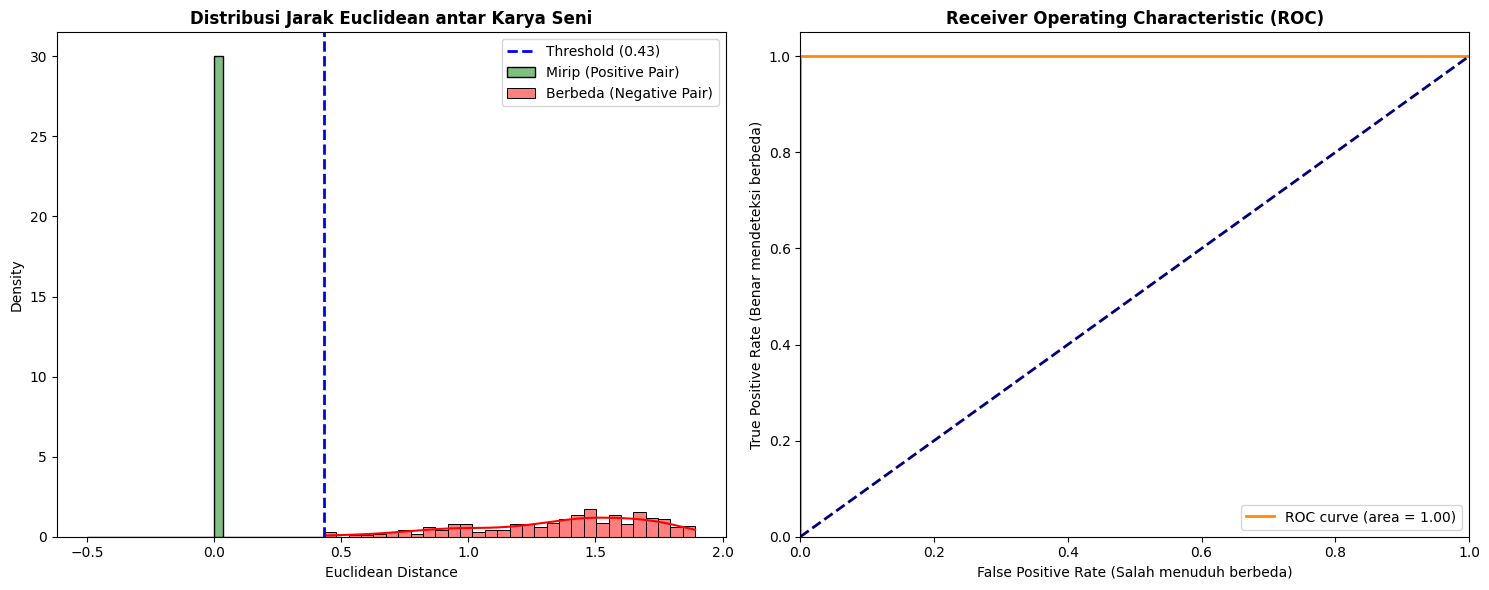


--- TAHAP PENGUJIAN FINAL (DATA TEST) ---


Extracting Distances:   0%|          | 0/29 [00:00<?, ?it/s]


[INFO] Mengevaluasi Data Uji (FINAL TESTING)...
--- HASIL FINAL TESTING ---
Accuracy  : 100.00% (Persentase tebakan benar secara keseluruhan)
Precision : 100.00% (Saat menebak 'Mirip', seberapa akurat tebakan tersebut)
Recall    : 100.00% (Dari seluruh lukisan 'Mirip', berapa persen yang berhasil terdeteksi)
F1-Score  : 100.00% (Keseimbangan antara Precision dan Recall)

[RESULT] Workflow Model Development Tahap 4 Selesai!


In [12]:
def extract_distances_and_labels(model, dataloader, device):
    """Mengekstrak jarak Euclidean dan label asli dari dataloader"""
    model.eval()
    distances = []
    true_labels = []
    
    with torch.no_grad():
        progress_bar = tqdm(dataloader, desc="Extracting Distances", leave=False)
        for img1, img2, labels in progress_bar:
            img1, img2 = img1.to(device), img2.to(device)
            
            out1, out2 = model(img1, img2)
            # Hitung jarak L2
            dist = F.pairwise_distance(out1, out2).cpu().numpy()
            
            distances.extend(dist)
            true_labels.extend(labels.numpy())
            
    return np.array(distances), np.array(true_labels)

def calibrate_threshold(distances, labels):
    """Menemukan threshold optimal menggunakan ROC Curve dan Youden's J statistic"""
    print("[INFO] Melakukan Kalibrasi Threshold...")
    
    # ROC Curve mengasumsikan label 1 adalah kelas positif (jarak tinggi).
    # Namun pada Siamese, 'Mirip' (Label 1) memiliki jarak yang RENDAH.
    # Oleh karena itu, kita invers jaraknya (menjadi kemiripan) atau invers labelnya.
    # Disini kita invers label untuk perhitungan ROC (Label 0 jadi 1 (berbeda/jarak jauh))
    inverted_labels = 1 - labels 
    
    fpr, tpr, thresholds = roc_curve(inverted_labels, distances)
    roc_auc = auc(fpr, tpr)
    
    # Youden's J statistic untuk mencari threshold terbaik
    # Rumus: J = Sensitivity (TPR) + Specificity (1 - FPR) - 1
    optimal_idx = np.argmax(tpr - fpr)
    optimal_threshold = thresholds[optimal_idx]
    
    print(f"[RESULT] Optimal Distance Threshold: {optimal_threshold:.4f}")
    print(f"[RESULT] ROC AUC Score: {roc_auc:.4f} (Mendekati 1.0 sangat baik)")
    
    return optimal_threshold, fpr, tpr, roc_auc

def plot_evaluation(distances, labels, threshold, fpr, tpr, roc_auc):
    """Memvisualisasikan Distribusi Jarak dan Kurva ROC"""
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # 1. Plot Histogram Distribusi Jarak
    pos_dists = distances[labels == 1]
    neg_dists = distances[labels == 0]
    
    sns.histplot(pos_dists, color='green', label='Mirip (Positive Pair)', kde=True, ax=axes[0], stat='density', bins=30, alpha=0.5)
    sns.histplot(neg_dists, color='red', label='Berbeda (Negative Pair)', kde=True, ax=axes[0], stat='density', bins=30, alpha=0.5)
    axes[0].axvline(threshold, color='blue', linestyle='--', linewidth=2, label=f'Threshold ({threshold:.2f})')
    
    axes[0].set_title('Distribusi Jarak Euclidean antar Karya Seni', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Euclidean Distance')
    axes[0].set_ylabel('Density')
    axes[0].legend()
    
    # 2. Plot ROC Curve
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate (Salah menuduh berbeda)')
    axes[1].set_ylabel('True Positive Rate (Benar mendeteksi berbeda)')
    axes[1].set_title('Receiver Operating Characteristic (ROC)', fontsize=12, fontweight='bold')
    axes[1].legend(loc="lower right")
    
    plt.tight_layout()
    plt.show()

def evaluate_test_set(distances, labels, threshold):
    """Menghitung metrik klasifikasi final pada data Test"""
    print("\n[INFO] Mengevaluasi Data Uji (FINAL TESTING)...")
    # Prediksi: 1 (Mirip) jika jarak <= threshold, sebaliknya 0 (Berbeda)
    predictions = (distances <= threshold).astype(int)
    
    acc = accuracy_score(labels, predictions)
    prec = precision_score(labels, predictions)
    rec = recall_score(labels, predictions)
    f1 = f1_score(labels, predictions)
    
    print("--- HASIL FINAL TESTING ---")
    print(f"Accuracy  : {acc * 100:.2f}% (Persentase tebakan benar secara keseluruhan)")
    print(f"Precision : {prec * 100:.2f}% (Saat menebak 'Mirip', seberapa akurat tebakan tersebut)")
    print(f"Recall    : {rec * 100:.2f}% (Dari seluruh lukisan 'Mirip', berapa persen yang berhasil terdeteksi)")
    print(f"F1-Score  : {f1 * 100:.2f}% (Keseimbangan antara Precision dan Recall)")

# ==========================================
# EKSEKUSI TAHAP 4
# ==========================================
if __name__ == "__main__":
    print("[INFO] Memulai Tahap 4: Kalibrasi dan Evaluasi Final")
    PROJECT_ART_PATH = r"C:\Users\laygenda surya putra\Documents\KULIAH\Semester 5\project-art-market\galeria\Similarity image Art to Art"
    MODEL_SAVE_PATH = os.path.join(PROJECT_ART_PATH, "model", "best_siamese_convnext.pth")
    
    # 1. Memuat bobot model terbaik dari Epoch 12
    # Asumsi variabel 'model', 'val_loader', 'test_loader', 'device' masih ada di memori
    model.load_state_dict(torch.load(MODEL_SAVE_PATH))
    model = model.to(device)
    print(f"[INFO] Berhasil memuat bobot model terbaik dari: {MODEL_SAVE_PATH}")
    
    # 2. Validasi & Kalibrasi Threshold
    print("\n--- TAHAP KALIBRASI (DATA VALIDASI) ---")
    val_distances, val_labels = extract_distances_and_labels(model, val_loader, device)
    optimal_threshold, fpr, tpr, roc_auc = calibrate_threshold(val_distances, val_labels)
    
    # Visualisasi
    plot_evaluation(val_distances, val_labels, optimal_threshold, fpr, tpr, roc_auc)
    
    # 3. Final Testing
    print("\n--- TAHAP PENGUJIAN FINAL (DATA TEST) ---")
    test_distances, test_labels = extract_distances_and_labels(model, test_loader, device)
    evaluate_test_set(test_distances, test_labels, optimal_threshold)
    
    print("\n[RESULT] Workflow Model Development Tahap 4 Selesai!")

## **G. GALERIA SIMILARITY ENGINE**

Mesin ini tidak membandingkan gambar satu per satu secara manual, melainkan:

- Mengekstrak embedding (vektor matriks) dari seluruh 3000 gambar asli di database dan menyimpannya.

- Saat ada gambar baru yang diunggah, mesin hanya perlu mengekstrak 1 embedding dari gambar tersebut.

- Mencari jarak terdekat (di bawah threshold 0.4315) antara gambar unggahan dengan 3000 gambar di database secara instan.

[INFO] Galeria Engine Diinisialisasi (Threshold: 0.1)
[INFO] Membangun Database Embedding dari C:\Users\laygenda surya putra\Documents\KULIAH\Semester 5\project-art-market\galeria\similarity image AI\data\REAL\cleaned_artworks_metadata.csv (Mohon tunggu)...
[RESULT] Database selesai dibangun. Total karya seni terekam: 2999

[INFO] Memproses pencarian untuk: Albrecht_Du╠êrer_1.jpg
[RESULT] PERINGATAN: Ditemukan 1 karya seni terindikasi duplikasi!


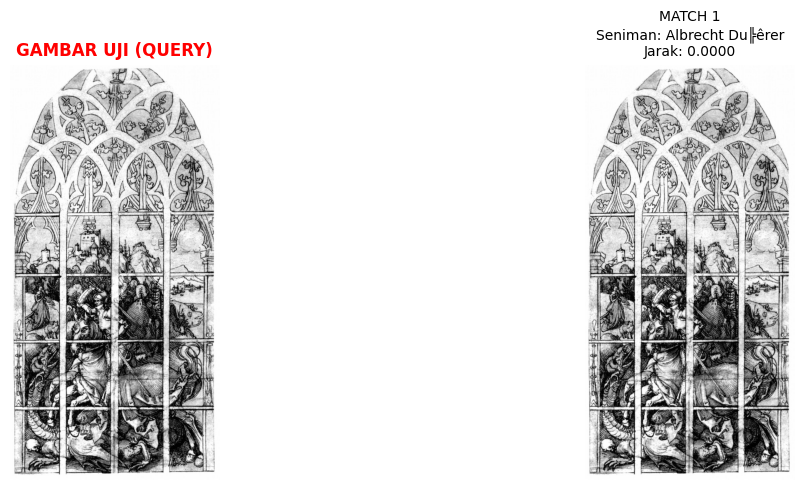

In [17]:
# ==========================================
# 1. INISIALISASI ENGINE & DATABASE EMBEDDING
# ==========================================
class GaleriaSimilarityEngine:
    def __init__(self, model, device, threshold, transform):
        self.model = model
        self.model.eval()
        self.device = device
        self.threshold = threshold
        self.transform = transform
        
        self.database_embeddings = None
        self.database_metadata = None
        print(f"[INFO] Galeria Engine Diinisialisasi (Threshold: {self.threshold})")

    def build_database(self, csv_path, img_dir):
        """Mengekstrak dan menyimpan embedding dari seluruh dataset lukisan asli"""
        print(f"[INFO] Membangun Database Embedding dari {csv_path} (Mohon tunggu)...")
        df = pd.read_csv(csv_path)
        
        embeddings = []
        valid_records = []
        
        with torch.no_grad():
            for idx, row in df.iterrows():
                img_name = row['Cleaned_File_Name']
                img_path = os.path.join(img_dir, img_name)
                
                try:
                    img = Image.open(img_path).convert('RGB')
                    img_tensor = self.transform(img).unsqueeze(0).to(self.device) 
                    
                    emb = self.model.forward_once(img_tensor)
                    embeddings.append(emb.cpu().numpy())
                    valid_records.append(row)
                    
                except Exception as e:
                    print(f"[WARNING] Gagal memproses {img_name}: {e}")
                    
        self.database_embeddings = np.vstack(embeddings)
        self.database_metadata = pd.DataFrame(valid_records)
        print(f"[RESULT] Database selesai dibangun. Total karya seni terekam: {len(self.database_metadata)}")
        
    def search_similarity(self, query_img_path, top_k=3):
        """Mencari lukisan yang mirip dengan gambar query"""
        if self.database_embeddings is None:
            raise ValueError("Database kosong! Jalankan build_database() terlebih dahulu.")
            
        print(f"\n[INFO] Memproses pencarian untuk: {os.path.basename(query_img_path)}")
        
        query_img = Image.open(query_img_path).convert('RGB')
        query_tensor = self.transform(query_img).unsqueeze(0).to(self.device)
        
        with torch.no_grad():
            query_emb = self.model.forward_once(query_tensor).cpu().numpy()
            
        distances = np.linalg.norm(self.database_embeddings - query_emb, axis=1)
        self.database_metadata['Distance'] = distances
        
        similar_artworks = self.database_metadata[self.database_metadata['Distance'] <= self.threshold].copy()
        
        if similar_artworks.empty:
            print("[RESULT] AMAN: Tidak ditemukan indikasi duplikasi atau plagiasi karya seni.")
            return None, query_img
            
        similar_artworks = similar_artworks.sort_values(by='Distance').head(top_k)
        print(f"[RESULT] PERINGATAN: Ditemukan {len(similar_artworks)} karya seni terindikasi duplikasi!")
        
        return similar_artworks, query_img

    def display_results(self, similar_artworks, query_img, db_img_dir):
        """Visualisasi hasil pencarian"""
        if similar_artworks is None:
            plt.figure(figsize=(4, 4))
            plt.imshow(query_img)
            plt.title("Query: AMAN (Tidak Ada Duplikat)", color='green')
            plt.axis('off')
            plt.show()
            return
            
        num_results = len(similar_artworks)
        fig, axes = plt.subplots(1, num_results + 1, figsize=(15, 5))
        
        axes[0].imshow(query_img)
        axes[0].set_title("GAMBAR UJI (QUERY)", fontweight='bold', color='red')
        axes[0].axis('off')
        
        for i, (_, row) in enumerate(similar_artworks.iterrows()):
            ax = axes[i + 1]
            img_path = os.path.join(db_img_dir, row['Cleaned_File_Name'])
            match_img = Image.open(img_path)
            
            ax.imshow(match_img)
            ax.set_title(f"MATCH {i+1}\nSeniman: {row['Artist']}\nJarak: {row['Distance']:.4f}", fontsize=10)
            ax.axis('off')
            
        plt.tight_layout()
        plt.show()

# ==========================================
# EKSEKUSI TAHAP 5: SIMILARITY ENGINE
# ==========================================
if __name__ == "__main__":
    PROJECT_ART_PATH = r"C:\Users\laygenda surya putra\Documents\KULIAH\Semester 5\project-art-market\galeria\Similarity image Art to Art"
    DATA_SOURCE_PATH = r"C:\Users\laygenda surya putra\Documents\KULIAH\Semester 5\project-art-market\galeria\similarity image AI"
    
    METADATA_CSV = os.path.join(DATA_SOURCE_PATH, "data", "REAL", "cleaned_artworks_metadata.csv")
    CLEANED_IMG_DIR = os.path.join(DATA_SOURCE_PATH, "data", "REAL", "art_3000_cleaned")
    
    # Menggunakan Empirical Threshold (0.10) yang jauh lebih ketat
    EMPIRICAL_THRESHOLD = 0.10
    
    # 1. Inisialisasi Engine
    engine = GaleriaSimilarityEngine(model=model, device=device, threshold=EMPIRICAL_THRESHOLD, transform=eval_transforms)
    
    # 2. Bangun Database (Baris ini WAJIB dijalankan agar array tidak None)
    engine.build_database(csv_path=METADATA_CSV, img_dir=CLEANED_IMG_DIR)
    
    # 3. Uji Coba Real-World
    # Gambar uji ini sebelumnya memunculkan 3 match. Dengan threshold 0.10, seharusnya hanya memunculkan dirinya sendiri (Match = 1).
    SAMPLE_TEST_IMAGE = os.path.join(CLEANED_IMG_DIR, "Albrecht_Du╠êrer_1.jpg") 
    
    # Menjalankan Pencarian
    results, q_img = engine.search_similarity(query_img_path=SAMPLE_TEST_IMAGE, top_k=3)
    
    # Visualisasi
    engine.display_results(results, q_img, CLEANED_IMG_DIR)

[INFO] Memulai Tahap 6: Evaluasi Komprehensif (Confusion Matrix & ROC)


C:\Users\laygenda surya putra\AppData\Local\Temp\ipykernel_4032\4079751695.py:90: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_SAVE_P

[INFO] Menguji model pada Test Set...


Extracting Distances:   0%|          | 0/29 [00:00<?, ?it/s]


[INFO] Mengevaluasi Performa Model dengan Threshold: 0.1

--- CLASSIFICATION REPORT ---
Accuracy  : 100.00%
Precision : 100.00%
Recall    : 100.00%
F1-Score  : 100.00%
ROC AUC   : 1.0000


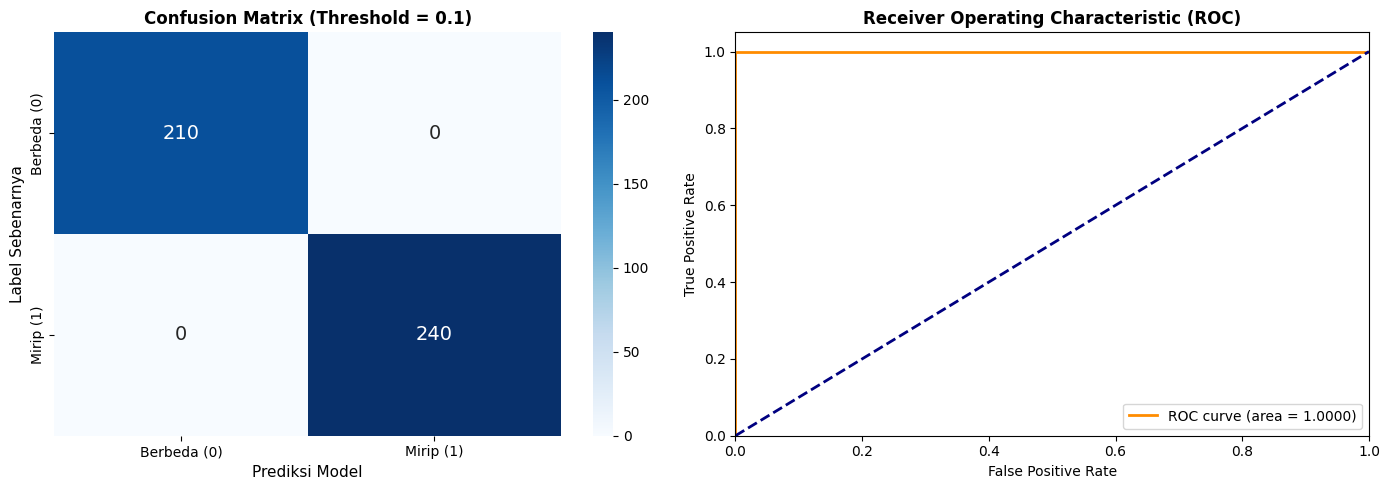

In [20]:
# ==========================================
# 1. FUNGSI EKSTRAKSI JARAK (RE-USE DARI TAHAP 4)
# ==========================================
def extract_distances_and_labels(model, dataloader, device):
    """Mengekstrak jarak Euclidean dan label asli dari dataloader"""
    model.eval()
    distances = []
    true_labels = []
    
    with torch.no_grad():
        progress_bar = tqdm(dataloader, desc="Extracting Distances", leave=False)
        for img1, img2, labels in progress_bar:
            img1, img2 = img1.to(device), img2.to(device)
            
            out1, out2 = model(img1, img2)
            dist = F.pairwise_distance(out1, out2).cpu().numpy()
            
            distances.extend(dist)
            true_labels.extend(labels.cpu().numpy())
            
    return np.array(distances), np.array(true_labels)

# ==========================================
# 2. FUNGSI EVALUASI KOMPREHENSIF
# ==========================================
def evaluate_engine_performance(distances, labels, threshold):
    print(f"\n[INFO] Mengevaluasi Performa Model dengan Threshold: {threshold}")
    
    # Prediksi: 1 (Mirip/Plagiat) jika jarak <= threshold, sebaliknya 0 (Aman/Berbeda)
    predictions = (distances <= threshold).astype(int)
    
    # Menghitung Metrik Utama
    acc = accuracy_score(labels, predictions)
    prec = precision_score(labels, predictions, zero_division=0)
    rec = recall_score(labels, predictions, zero_division=0)
    f1 = f1_score(labels, predictions, zero_division=0)
    
    # Menghitung ROC AUC (Ingat: Label 0 menjadi 1 untuk perhitungan ROC pada jarak)
    inverted_labels = 1 - labels 
    fpr, tpr, _ = roc_curve(inverted_labels, distances)
    roc_auc = auc(fpr, tpr)
    
    print("\n--- CLASSIFICATION REPORT ---")
    print(f"Accuracy  : {acc * 100:.2f}%")
    print(f"Precision : {prec * 100:.2f}%")
    print(f"Recall    : {rec * 100:.2f}%")
    print(f"F1-Score  : {f1 * 100:.2f}%")
    print(f"ROC AUC   : {roc_auc:.4f}")
    
    # Membangun Confusion Matrix
    cm = confusion_matrix(labels, predictions)
    
    # ==========================================
    # 3. VISUALISASI CONFUSION MATRIX & ROC
    # ==========================================
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot Confusion Matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Berbeda (0)', 'Mirip (1)'],
                yticklabels=['Berbeda (0)', 'Mirip (1)'],
                annot_kws={"size": 14})
    axes[0].set_title(f'Confusion Matrix (Threshold = {threshold})', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Prediksi Model', fontsize=11)
    axes[0].set_ylabel('Label Sebenarnya', fontsize=11)
    
    # Plot ROC Curve
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('Receiver Operating Characteristic (ROC)', fontsize=12, fontweight='bold')
    axes[1].legend(loc="lower right")
    
    plt.tight_layout()
    plt.show()

# ==========================================
# EKSEKUSI TAHAP 6: FINAL EVALUATION
# ==========================================
if __name__ == "__main__":
    print("[INFO] Memulai Tahap 6: Evaluasi Komprehensif (Confusion Matrix & ROC)")
    
    PROJECT_ART_PATH = r"C:\Users\laygenda surya putra\Documents\KULIAH\Semester 5\project-art-market\galeria\Similarity image Art to Art"
    MODEL_SAVE_PATH = os.path.join(PROJECT_ART_PATH, "model", "best_siamese_convnext.pth")
    
    # Memastikan model berjalan dengan bobot terbaik
    model.load_state_dict(torch.load(MODEL_SAVE_PATH))
    model = model.to(device)
    
    # Menggunakan parameter dari Tahap 5
    EMPIRICAL_THRESHOLD = 0.10
    
    # Ekstraksi jarak khusus dari data TEST (Unseen Data)
    # Asumsi test_loader sudah diinisialisasi di tahap DataLoader sebelumnya
    print("[INFO] Menguji model pada Test Set...")
    test_distances, test_labels = extract_distances_and_labels(model, test_loader, device)
    
    # Melakukan Evaluasi
    evaluate_engine_performance(test_distances, test_labels, threshold=EMPIRICAL_THRESHOLD)